## データベースを作成　

## スクレイピング

In [14]:
import requests
import time
from bs4 import BeautifulSoup
from urllib.parse import urljoin
import os

url = "https://www.meti.go.jp/statistics/tyo/sanzi/b2015_result-2.html"

headers = {
    "User-Agent": "Mozilla/5.0 (compatible; DataAnalysis/1.0)"
}

time.sleep(1)

res = requests.get(url, headers=headers, timeout=(5,10))
res.encoding = res.apparent_encoding

soup = BeautifulSoup(res.text, "html.parser")

excel_url = None
for a in soup.find_all("a"):
    href = a.get("href")
    if href and "b2015_koqj.xlsx" in href:
        excel_url = urljoin(url, href)
        break

print("Excel URL:", excel_url)

if not os.path.exists("b2015_koqj.xlsx"):
    excel_data = requests.get(excel_url, headers=headers, timeout=(5,10))
    with open("b2015_koqj.xlsx", "wb") as f:
        f.write(excel_data.content)
    print("Excel保存完了")
else:
    print("既にExcelは存在します")




Excel URL: https://www.meti.go.jp/statistics/tyo/sanzi/result/excel/b2015_koqj.xlsx
Excel保存完了


## 分析


In [24]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel(
    "b2015_koqj.xlsx",
    sheet_name="ITA",
)

target = df.iloc[210:212, 3:15]
target





,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14
210,100.2,98.2,100,97.9,93.4,91.5,86.9,49.4,44.1,62.8,73.4,77.1
211,89.4,92.5,100,98.2,99.6,102.7,112.4,63.5,67,96.5,128.1,134.5


## 可視化

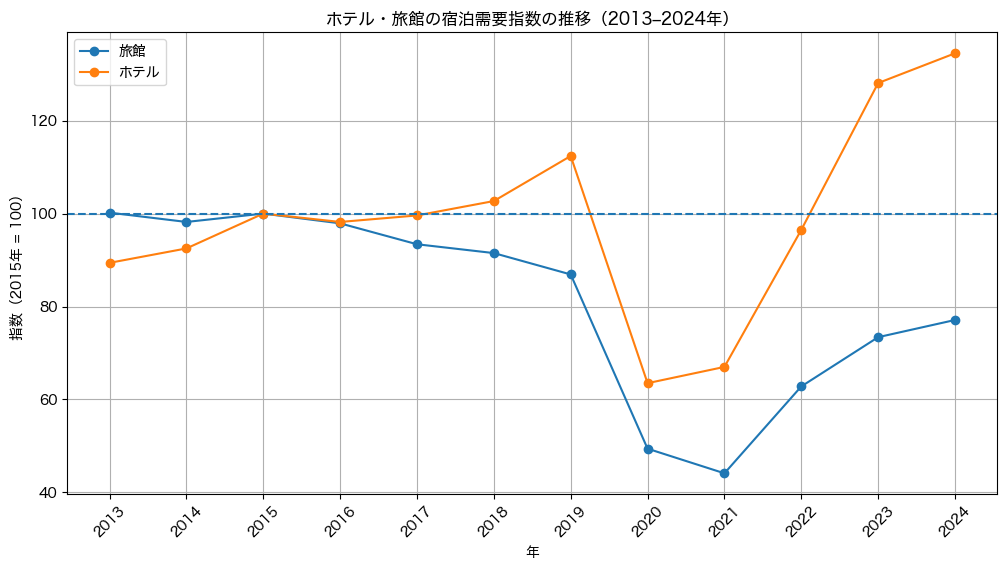

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
rcParams["font.family"] = "Hiragino Sans"

df = pd.read_excel("b2015_koqj.xlsx", sheet_name="ITA")

# 212・213行目（ホテル・旅館）＋ D〜O列（2013〜2024年）
target = df.iloc[210:212, 3:15]

# 年リストを明示的に作成
years = list(range(2013, 2025))

# 転置
plot_df = target.T
plot_df.columns = ["ryokan", "hotel"]

# 折れ線グラフ
plt.figure(figsize=(12, 6))
plt.plot(years, plot_df["ryokan"], marker="o", label="旅館")
plt.plot(years, plot_df["hotel"], marker="o", label="ホテル")

plt.axhline(100, linestyle="--")  # 2015年基準線
plt.xlabel("年")
plt.ylabel("指数（2015年 = 100）")
plt.title("ホテル・旅館の宿泊需要指数の推移（2013–2024年）")
plt.legend()
plt.grid(True)
plt.xticks(years, rotation=45)

plt.show()



